In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [33]:
df = pd.read_csv('/content/ABCA4_mutations_annotated_with_features.csv')

# Display basic information and statistics
print('--- Dataset Info ---')
display(df.info())
print('\n--- Column Names ---')
print(df.columns.tolist())
print('\n--- Descriptive Statistics ---')
display(df.describe(include='all'))
print('\n--- First 5 Rows ---')
display(df.head())
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Null Values ---')
print(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3915 entries, 0 to 3914
Columns: 137 entries, Variant to DDmut_score
dtypes: float64(17), int64(116), object(4)
memory usage: 4.1+ MB


None


--- Column Names ---
['Variant', 'Significance', 'Source', 'Annotation', 'Position', 'Covalent', 'VDWClash', 'VDW', 'Proximal', 'Hbond', 'WeakHbond', 'Ionic', 'Aromatic', 'Hydrophobic', 'Carbonyl', 'Polar', 'WeakPolar', 'PI-PI', 'Carbon-PI', 'Cation-PI', 'Donor-PI', 'MetalSulphur-PI', 'Amide-Amide', 'Amide-Ring', 'd_Covalent', 'd_VDWClash', 'd_VDW', 'd_Proximal', 'd_Hbond', 'd_WeakHbond', 'd_Ionic', 'd_Aromatic', 'd_Hydrophobic', 'd_Carbonyl', 'd_Polar', 'd_WeakPolar', 'd_PI-PI', 'd_Carbon-PI', 'd_Cation-PI', 'd_Donor-PI', 'd_MetalSulphur-PI', 'd_Amide-Amide', 'd_Amide-Ring', 'Hydro', 'Pos', 'Neg', 'Acc', 'Don', 'Aro', 'Sul', 'Neutral', 'HH:12.00', 'PP:12.00', 'HP_12_00', 'HH:11.50', 'PP:11.50', 'HP:11.50', 'HH:11.00', 'PP:11.00', 'HP:11.00', 'HH:10.50', 'PP:10.50', 'HP:10.50', 'HH:10.00', 'PP:10.00', 'HP:10.00', 'HH:9.50', 'PP:9.50', 'HP:9.50', 'HH:9.00', 'PP:9.00', 'HP:9.00', 'HH:8.50', 'PP:8.50', 'HP:8.50', 'HH:8.00', 'PP:8.00', 'HP:8.00', 'HH:7.50', 'PP:7.50', 'HP:7.50', 'HH:7.00'

,Variant,Significance,Source,Annotation,Position,Covalent,VDWClash,VDW,Proximal,Hbond,...,Envision_AA2_PSIC,Envision_delta_PSIC,Demask_matrix,Demask_log2f_var,Demask_entropy,Consurf_score,MTR_score,IUPRED_score,ANCHOR_score,DDmut_score
count,3915,3915,3915,3915,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,...,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000,3915.000000
unique,3915,3,5,13,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,D999G,Benign,gnomAD,Unannotated,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1803,1743,3850,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1147.694764,0.009195,1.988761,1.157344,66.409706,2.096041,...,-3.149472,1.473277,-0.224934,-13.477640,1.190208,-0.042256,0.917407,0.189012,0.236566,-0.575357
std,NaN,NaN,NaN,NaN,656.758228,0.095463,1.725067,1.214488,33.609038,1.483506,...,0.802610,1.110783,0.089160,8.516058,1.056116,1.002173,0.092960,0.189378,0.160268,0.863914
min,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-5.723000,-2.054000,-0.490600,-22.253500,0.000100,-1.110000,0.574000,0.000500,0.000000,-4.467615
25%,NaN,NaN,NaN,NaN,583.500000,0.000000,1.000000,0.000000,44.000000,1.000000,...,-3.628000,0.629000,-0.291100,-22.228750,0.137950,-0.862000,0.852000,0.040950,0.070800,-1.012271
50%,NaN,NaN,NaN,NaN,1143.000000,0.000000,2.000000,1.000000,67.000000,2.000000,...,-3.058000,1.366000,-0.200300,-8.959900,1.062100,-0.373000,0.924000,0.139000,0.264500,-0.269939
75%,NaN,NaN,NaN,NaN,1713.000000,0.000000,3.000000,2.000000,86.000000,3.000000,...,-2.609000,2.258000,-0.158000,-5.469800,2.009950,0.526000,0.981000,0.277750,0.374400,0.035999



--- First 5 Rows ---


,Variant,Significance,Source,Annotation,Position,Covalent,VDWClash,VDW,Proximal,Hbond,...,Envision_AA2_PSIC,Envision_delta_PSIC,Demask_matrix,Demask_log2f_var,Demask_entropy,Consurf_score,MTR_score,IUPRED_score,ANCHOR_score,DDmut_score
0,M1V,Pathogenic,ClinVar,Severe (10),1,0,0,0,15,0,...,-2.896,1.973,-0.1978,-21.6186,0.0305,-0.981,0.775,0.0052,0.0002,-0.023340
1,M1L,Pathogenic,ClinVar,Unannotated,1,0,0,0,15,0,...,-2.501,1.578,-0.1126,-8.3308,0.0305,-0.981,0.775,0.0052,0.0002,0.030191
2,M1T,Pathogenic,ClinVar,Unannotated,1,0,0,0,15,0,...,-3.464,2.541,-0.2263,-21.6186,0.0305,-0.981,0.775,0.0052,0.0002,0.008176
3,M1I,Pathogenic,ClinVar,Unannotated,1,0,0,0,15,0,...,-3.153,2.230,-0.1558,-21.6186,0.0305,-0.981,0.775,0.0052,0.0002,-0.073016
4,L10F,Benign,gnomAD,Unannotated,10,0,2,2,108,2,...,-3.746,2.997,-0.2003,-22.0190,0.0001,-0.968,0.839,0.0185,0.0003,-0.601935



--- Data Types ---
Variant           object
Significance      object
Source            object
Annotation        object
Position           int64
                  ...   
Consurf_score    float64
MTR_score        float64
IUPRED_score     float64
ANCHOR_score     float64
DDmut_score      float64
Length: 137, dtype: object

--- Null Values ---
Variant          0
Significance     0
Source           0
Annotation       0
Position         0
                ..
Consurf_score    0
MTR_score        0
IUPRED_score     0
ANCHOR_score     0
DDmut_score      0
Length: 137, dtype: int64


In [34]:
# ─── Section 2: Label Encoding + Split into Labelled vs VUS ───────────────

# Step 1: Separate metadata/label columns from numeric feature columns
metadata_cols = ['Variant', 'Significance', 'Source', 'Annotation']

# All columns that are NOT metadata are candidate features
feature_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")

Number of feature columns: 133
Feature columns: ['Position', 'Covalent', 'VDWClash', 'VDW', 'Proximal', 'Hbond', 'WeakHbond', 'Ionic', 'Aromatic', 'Hydrophobic', 'Carbonyl', 'Polar', 'WeakPolar', 'PI-PI', 'Carbon-PI', 'Cation-PI', 'Donor-PI', 'MetalSulphur-PI', 'Amide-Amide', 'Amide-Ring', 'd_Covalent', 'd_VDWClash', 'd_VDW', 'd_Proximal', 'd_Hbond', 'd_WeakHbond', 'd_Ionic', 'd_Aromatic', 'd_Hydrophobic', 'd_Carbonyl', 'd_Polar', 'd_WeakPolar', 'd_PI-PI', 'd_Carbon-PI', 'd_Cation-PI', 'd_Donor-PI', 'd_MetalSulphur-PI', 'd_Amide-Amide', 'd_Amide-Ring', 'Hydro', 'Pos', 'Neg', 'Acc', 'Don', 'Aro', 'Sul', 'Neutral', 'HH:12.00', 'PP:12.00', 'HP_12_00', 'HH:11.50', 'PP:11.50', 'HP:11.50', 'HH:11.00', 'PP:11.00', 'HP:11.00', 'HH:10.50', 'PP:10.50', 'HP:10.50', 'HH:10.00', 'PP:10.00', 'HP:10.00', 'HH:9.50', 'PP:9.50', 'HP:9.50', 'HH:9.00', 'PP:9.00', 'HP:9.00', 'HH:8.50', 'PP:8.50', 'HP:8.50', 'HH:8.00', 'PP:8.00', 'HP:8.00', 'HH:7.50', 'PP:7.50', 'HP:7.50', 'HH:7.00', 'PP:7.00', 'HP:7.00', '

In [35]:
# Step 2: Split the dataset into labelled variants and VUS
labelled = df[df['Significance'].isin(['Benign', 'Pathogenic'])].copy()
vus = df[df['Significance'] == 'VUS'].copy()

print(f"Labelled variants (Benign + Pathogenic): {len(labelled)}")
print(f"  Benign:     {(labelled['Significance'] == 'Benign').sum()}")
print(f"  Pathogenic: {(labelled['Significance'] == 'Pathogenic').sum()}")
print(f"\nVUS variants (held out for reclassification): {len(vus)}")

Labelled variants (Benign + Pathogenic): 3103
  Benign:     1803
  Pathogenic: 1300

VUS variants (held out for reclassification): 812


In [36]:
# Step 3: Encode the binary label (Benign=0, Pathogenic=1)
labelled['label'] = labelled['Significance'].map({'Benign': 0, 'Pathogenic': 1})

print("\nLabel distribution:")
print(labelled['label'].value_counts())
print(f"\nClass balance: {labelled['label'].mean():.1%} pathogenic")


Label distribution:
label
0    1803
1    1300
Name: count, dtype: int64

Class balance: 41.9% pathogenic


In [37]:
# ─── Section 3: Build X and y ─────────────────────────────────────────────

X = labelled[feature_cols].copy()
y = labelled['label'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 labels of y:")
display(y.head())

X shape: (3103, 133)
y shape: (3103,)

First 5 rows of X:


,Position,Covalent,VDWClash,VDW,Proximal,Hbond,WeakHbond,Ionic,Aromatic,Hydrophobic,...,Envision_AA2_PSIC,Envision_delta_PSIC,Demask_matrix,Demask_log2f_var,Demask_entropy,Consurf_score,MTR_score,IUPRED_score,ANCHOR_score,DDmut_score
0,1,0,0,0,15,0,0,0,0,0,...,-2.896,1.973,-0.1978,-21.6186,0.0305,-0.981,0.775,0.0052,0.0002,-0.023340
1,1,0,0,0,15,0,0,0,0,0,...,-2.501,1.578,-0.1126,-8.3308,0.0305,-0.981,0.775,0.0052,0.0002,0.030191
2,1,0,0,0,15,0,0,0,0,0,...,-3.464,2.541,-0.2263,-21.6186,0.0305,-0.981,0.775,0.0052,0.0002,0.008176
3,1,0,0,0,15,0,0,0,0,0,...,-3.153,2.230,-0.1558,-21.6186,0.0305,-0.981,0.775,0.0052,0.0002,-0.073016
4,10,0,2,2,108,2,2,0,0,8,...,-3.746,2.997,-0.2003,-22.0190,0.0001,-0.968,0.839,0.0185,0.0003,-0.601935



First 5 labels of y:


,label
0,1
1,1
2,1
3,1
4,0


In [38]:
# ─── Section 4: Train / Test Split ────────────────────────────────────────
from sklearn.model_selection import train_test_split

# Split: 80% train, 20% test
# stratify=y ensures each split maintains the ~58/42 Benign/Pathogenic ratio
# random_state=42 makes the split reproducible (same result every run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape[0]} rows")
print(f"Test set:       {X_test.shape[0]} rows")
print()
print("Training label distribution:")
print(y_train.value_counts())
print(f"  Class balance: {y_train.mean():.1%} pathogenic")
print()
print("Test label distribution:")
print(y_test.value_counts())
print(f"  Class balance: {y_test.mean():.1%} pathogenic")

# ─── Also prepare the VUS feature matrix ─────────────────────────────────
X_vus = vus[feature_cols].copy()

print(f"\nVUS feature matrix shape: {X_vus.shape}")

Training set:   2482 rows
Test set:       621 rows

Training label distribution:
label
0    1442
1    1040
Name: count, dtype: int64
  Class balance: 41.9% pathogenic

Test label distribution:
label
0    361
1    260
Name: count, dtype: int64
  Class balance: 41.9% pathogenic

VUS feature matrix shape: (812, 133)


In [39]:
# ─── Section 5: Feature Scaling + Logistic Regression Baseline ────────────
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef, roc_auc_score
import numpy as np

# Step 1: Scale features
# Fit ONLY on X_train — never on X_test or X_vus
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit + transform training data
X_test_scaled  = scaler.transform(X_test) # transform only — no fitting
X_vus_scaled   = scaler.transform(X_vus) # transform only — no fitting

print("Scaling complete.")
print(f"X_train_scaled median (should be ~0): {np.median(X_train_scaled):.4f}")
print(f"X_train_scaled Global IQR: {np.percentile(X_train_scaled, 75) - np.percentile(X_train_scaled, 25):.4f}")

# Step 2: Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Define scoring metrics
scoring = {
    'roc_auc':           'roc_auc',
    'average_precision': 'average_precision',
    'f1':                'f1',
    'mcc':      make_scorer(matthews_corrcoef),
    'recall':            'recall',
    'precision':         'precision'
}

# Step 4: Logistic Regression with L2 regularisation
lr = LogisticRegression(
    C=1.0,              # regularisation strength (smaller = more regularised)
    max_iter=1000,      # enough iterations to converge on 133 features
    random_state=42,
    class_weight='balanced'  # adjusts for slight class imbalance
)

# Step 5: Cross-validate
lr_cv = cross_validate(lr, X_train_scaled, y_train, cv=cv, scoring=scoring)

# Step 6: Report cross-validation results
print("\n─── Logistic Regression (5-fold CV) ───")
for metric, values in lr_cv.items():
    if metric.startswith('test_'):
        name = metric.replace('test_', '')
        print(f"  {name:12s}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Scaling complete.
X_train_scaled median (should be ~0): 0.0000
X_train_scaled Global IQR: 0.7802

─── Logistic Regression (5-fold CV) ───
  roc_auc     : 0.7264 ± 0.0226
  average_precision: 0.6544 ± 0.0203
  f1          : 0.6211 ± 0.0272
  mcc         : 0.3309 ± 0.0514
  recall      : 0.6442 ± 0.0256
  precision   : 0.5998 ± 0.0302


In [40]:
# ─── Section 6: Random Forest ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

# Note: Random Forest does NOT need scaled features
# Tree-based models split on thresholds — scale is irrelevant
# We use X_train, X_test directly (not the scaled versions)

rf = RandomForestClassifier(
    n_estimators=500,        # 500 trees — stable predictions, diminishing returns above this
    class_weight='balanced', # accounts for Benign (1803) > Pathogenic (1300) imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores — speeds up training significantly
)

# Cross-validate using SAME cv and scoring objects defined in Section 5
# This ensures results are directly comparable to Logistic Regression
rf_cv = cross_validate(rf, X_train, y_train, cv=cv, scoring=scoring)

print("\n─── Random Forest (5-fold CV) ───")
for metric, values in rf_cv.items():
    if metric.startswith('test_'):
        name = metric.replace('test_', '')
        print(f"  {name:12s}: {np.mean(values):.4f} ± {np.std(values):.4f}")


─── Random Forest (5-fold CV) ───
  roc_auc     : 0.7195 ± 0.0177
  average_precision: 0.6545 ± 0.0182
  f1          : 0.5811 ± 0.0172
  mcc         : 0.3366 ± 0.0179
  recall      : 0.5250 ± 0.0261
  precision   : 0.6516 ± 0.0100


In [41]:
# ─── Section 7: XGBoost ───────────────────────────────────────────────────
from xgboost import XGBClassifier
import numpy as np

# Calculate scale_pos_weight — equivalent to class_weight='balanced' for XGBoost
# Formula: count of negative class / count of positive class
neg = np.sum(y_train == 0)  # Benign count
pos = np.sum(y_train == 1)  # Pathogenic count
spw = neg / pos             # if Benign=1400, Pathogenic=1000 → spw=1.4

print(f"Benign (0): {neg}, Pathogenic (1): {pos}")
print(f"scale_pos_weight: {spw:.4f}")

# XGBoost with hyperparameters informed by XGBMut paper (Pereira et al. 2025)
xgb = XGBClassifier(
    n_estimators=500,          # number of boosting rounds (trees)
    learning_rate=0.1,         # shrinks each tree's contribution — reduces overfitting
    max_depth=10,              # maximum depth of each tree — allows complex interactions
    colsample_bytree=0.5,      # use 50% of features per tree — reduces correlation between trees
    reg_lambda=1.0,            # L2 regularisation on leaf weights — prevents overfitting
    scale_pos_weight=spw,      # compensates for class imbalance
    random_state=42,
    eval_metric='logloss',     # internal evaluation metric during training
    verbosity=0,               # suppress training output
    n_jobs=-1
)

# Cross-validate — same cv and scoring as LR and RF for direct comparison
xgb_cv = cross_validate(xgb, X_train, y_train, cv=cv, scoring=scoring)

print("\n─── XGBoost (5-fold CV) ───")
for metric, values in xgb_cv.items():
    if metric.startswith('test_'):
        name = metric.replace('test_', '')
        print(f"  {name:12s}: {np.mean(values):.4f} ± {np.std(values):.4f}")

Benign (0): 1442, Pathogenic (1): 1040
scale_pos_weight: 1.3865

─── XGBoost (5-fold CV) ───
  roc_auc     : 0.7134 ± 0.0168
  average_precision: 0.6417 ± 0.0168
  f1          : 0.5868 ± 0.0178
  mcc         : 0.3118 ± 0.0234
  recall      : 0.5625 ± 0.0262
  precision   : 0.6138 ± 0.0118


In [46]:
# ─── Feature Selection: Keep only statistically significant features ───────

# Keep features with p < 0.05 from Mann-Whitney test
significant_features = sep_df[sep_df['p_value'] < 0.05]['feature'].tolist()
print(f"Features retained (p < 0.05): {len(significant_features)} / 133")

# Apply to all splits — no fitting needed, this is just column selection
X_train_selected = X_train[significant_features]
X_test_selected  = X_test[significant_features]
X_vus_selected   = X_vus[significant_features]

print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected shape:  {X_test_selected.shape}")

Features retained (p < 0.05): 101 / 133
X_train_selected shape: (2482, 101)
X_test_selected shape:  (621, 101)


In [47]:
# ─── Step: Aggressive contact feature pruning ─────────────────────────────
# Keep only 3 representative distance cutoffs per contact type
# Short range (4.0Å), Medium range (7.0Å), Long range (11.0Å)
# This reduces 64 contact columns → ~12 representative ones

keep_distances = ['4.00', '7.00', '11.00']

# From significant_features, keep non-contact features + selected contact distances
pruned_features = []
for f in significant_features:
    is_contact = any(f.startswith(p) for p in ['HH:', 'PP:', 'HP:', 'PH:'])
    if not is_contact:
        pruned_features.append(f)        # always keep non-contact features
    else:
        dist = f.split(':')[1]           # extract distance e.g. '7.00'
        if dist in keep_distances:
            pruned_features.append(f)    # only keep the 3 representative distances

print(f"Features after contact pruning: {len(pruned_features)}")
print(f"  Non-contact features: {sum(1 for f in pruned_features if not any(f.startswith(p) for p in ['HH:','PP:','HP:','PH:']))}")
print(f"  Contact features kept: {sum(1 for f in pruned_features if any(f.startswith(p) for p in ['HH:','PP:','HP:','PH:']))}")

X_train_pruned = X_train[pruned_features].copy()
X_test_pruned  = X_test[pruned_features].copy()
X_vus_pruned   = X_vus[pruned_features].copy()

Features after contact pruning: 46
  Non-contact features: 37
  Contact features kept: 9


In [50]:
# This will be added after diagnostic 4
X_train_pruned['Consurf_x_Envision'] = (
    X_train_pruned['Consurf_score'] * X_train_pruned['Envision_delta_PSIC']
)

In [51]:
# ─── Section 10: Interaction Features + Clean Rebuild ─────────────────────

# Step 1: Rebuild pruned DataFrames as genuine independent copies
# This eliminates the SettingWithCopyWarning permanently
X_train_pruned = X_train[pruned_features].copy()
X_test_pruned  = X_test[pruned_features].copy()
X_vus_pruned   = X_vus[pruned_features].copy()

print("Rebuilt pruned DataFrames as independent copies.")
print(f"Starting shape: {X_train_pruned.shape}")

# ── Step 2: Add interaction features ──────────────────────────────────────
# Interaction terms capture multiplicative relationships that linear models
# and even tree-based models may miss when features act in combination.
#
# Biological reasoning for each interaction:
#
# 1. Consurf × Envision_delta_PSIC
#    High conservation (Consurf) + large substitution penalty (delta_PSIC)
#    = variant is in a critical, evolutionarily locked position AND the
#      substitution is biochemically unlikely → strongly pathogenic signal
#
# 2. DDmut_score × d_Hbond
#    Protein destabilisation (DDmut) AND hydrogen bond loss (d_Hbond)
#    = structural damage confirmed by two independent lines of evidence
#
# 3. Demask_entropy × Envision_delta_PSIC
#    Low sequence entropy (conserved position) + large PSIC change
#    = the position tolerates almost no variation, and this change is large
#
# 4. Consurf × d_VDWClash
#    Highly conserved position + steric clash introduced
#    = mutation is forcing an atomic collision at a position that cannot
#      tolerate any change

interactions = {
    'Consurf_x_Envision':   ('Consurf_score',       'Envision_delta_PSIC'),
    'DDmut_x_dHbond':       ('DDmut_score',          'd_Hbond'),
    'Demask_x_Envision':    ('Demask_entropy',        'Envision_delta_PSIC'),
    'Consurf_x_VDWClash':   ('Consurf_score',         'd_VDWClash'),
}

for new_col, (col_a, col_b) in interactions.items():
    X_train_pruned[new_col] = X_train_pruned[col_a] * X_train_pruned[col_b]
    X_test_pruned[new_col]  = X_test_pruned[col_a]  * X_test_pruned[col_b]
    X_vus_pruned[new_col]   = X_vus_pruned[col_a]   * X_vus_pruned[col_b]

print(f"Added {len(interactions)} interaction features.")
print(f"New shape: {X_train_pruned.shape}")
print(f"\nInteraction features added: {list(interactions.keys())}")

# Step 3: Verify the interactions have separating power
print("\n─── Mann-Whitney p-values for interaction features ───")
for new_col in interactions.keys():
    benign_vals     = X_train_pruned[new_col][y_train == 0]
    pathogenic_vals = X_train_pruned[new_col][y_train == 1]
    stat, p = mannwhitneyu(benign_vals, pathogenic_vals, alternative='two-sided')
    print(f"  {new_col:30s}: p = {p:.4e}")

Rebuilt pruned DataFrames as independent copies.
Starting shape: (2482, 46)
Added 4 interaction features.
New shape: (2482, 50)

Interaction features added: ['Consurf_x_Envision', 'DDmut_x_dHbond', 'Demask_x_Envision', 'Consurf_x_VDWClash']

─── Mann-Whitney p-values for interaction features ───
  Consurf_x_Envision            : p = 4.6824e-47
  DDmut_x_dHbond                : p = 6.4124e-02
  Demask_x_Envision             : p = 2.5049e-04
  Consurf_x_VDWClash            : p = 3.4753e-03


In [52]:
# ─── Section 11: Drop failed interaction + retrain with interactions ───────

# Step 1: Drop DDmut_x_dHbond — not significant (p = 0.064)
# Keeping non-significant engineered features adds noise without signal
cols_to_drop = ['DDmut_x_dHbond']

X_train_pruned = X_train_pruned.drop(columns=cols_to_drop).copy()
X_test_pruned  = X_test_pruned.drop(columns=cols_to_drop).copy()
X_vus_pruned   = X_vus_pruned.drop(columns=cols_to_drop).copy()

print(f"Final feature set shape: {X_train_pruned.shape}")
print(f"Features: {X_train_pruned.shape[1]} total")
print(f"  (46 pruned + 3 significant interactions - 0 dropped = 49)")

Final feature set shape: (2482, 49)
Features: 49 total
  (46 pruned + 3 significant interactions - 0 dropped = 49)


In [53]:
# Step 2: Refit scaler on final feature set for Logistic Regression
scaler_final = RobustScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_pruned)
X_test_final_scaled  = scaler_final.transform(X_test_pruned)

# Step 3: Retrain all three models
# We name these _final_cv to distinguish from previous runs
lr_final_cv  = cross_validate(lr,  X_train_final_scaled, y_train, cv=cv, scoring=scoring)
rf_final_cv  = cross_validate(rf,  X_train_pruned,       y_train, cv=cv, scoring=scoring)
xgb_final_cv = cross_validate(xgb, X_train_pruned,       y_train, cv=cv, scoring=scoring)

In [54]:
# Step 4: Three-way comparison — Original vs Pruned vs Final (with interactions)
print("─── Progressive improvement: Original → Pruned → Final ───\n")

for label, orig_cv, prun_cv, final_cv in [
    ('Logistic Regression', lr_cv,  lr_pruned_cv,  lr_final_cv),
    ('Random Forest',       rf_cv,  rf_pruned_cv,  rf_final_cv),
    ('XGBoost',             xgb_cv, xgb_pruned_cv, xgb_final_cv),
]:
    o_auc = np.mean(orig_cv['test_roc_auc'])
    p_auc = np.mean(prun_cv['test_roc_auc'])
    f_auc = np.mean(final_cv['test_roc_auc'])

    o_mcc = np.mean(orig_cv['test_mcc'])
    p_mcc = np.mean(prun_cv['test_mcc'])
    f_mcc = np.mean(final_cv['test_mcc'])

    print(f"{label}")
    print(f"  AUC-ROC: {o_auc:.4f} → {p_auc:.4f} → {f_auc:.4f}  "
          f"(total Δ {f_auc - o_auc:+.4f})")
    print(f"  MCC:     {o_mcc:.4f} → {p_mcc:.4f} → {f_mcc:.4f}  "
          f"(total Δ {f_mcc - o_mcc:+.4f})\n")

─── Progressive improvement: Original → Pruned → Final ───

Logistic Regression
  AUC-ROC: 0.7264 → 0.7233 → 0.7241  (total Δ -0.0023)
  MCC:     0.3309 → 0.3310 → 0.3345  (total Δ +0.0036)

Random Forest
  AUC-ROC: 0.7195 → 0.7228 → 0.7185  (total Δ -0.0010)
  MCC:     0.3366 → 0.3462 → 0.3378  (total Δ +0.0013)

XGBoost
  AUC-ROC: 0.7134 → 0.7131 → 0.7119  (total Δ -0.0015)
  MCC:     0.3118 → 0.3085 → 0.3118  (total Δ +0.0000)



In [55]:
# Step 5: Full metric summary of the final feature set
print("─── Full metric summary: Final feature set (49 features) ───")
for label, final_cv in [('Logistic Regression', lr_final_cv),
                          ('Random Forest',       rf_final_cv),
                          ('XGBoost',             xgb_final_cv)]:
    print(f"\n{label}")
    for metric, values in final_cv.items():
        if metric.startswith('test_'):
            name = metric.replace('test_', '')
            print(f"  {name:20s}: {np.mean(values):.4f} ± {np.std(values):.4f}")

─── Full metric summary: Final feature set (49 features) ───

Logistic Regression
  roc_auc             : 0.7241 ± 0.0246
  average_precision   : 0.6497 ± 0.0289
  f1                  : 0.6217 ± 0.0298
  mcc                 : 0.3345 ± 0.0539
  recall              : 0.6413 ± 0.0308
  precision           : 0.6033 ± 0.0302

Random Forest
  roc_auc             : 0.7185 ± 0.0189
  average_precision   : 0.6485 ± 0.0207
  f1                  : 0.5789 ± 0.0238
  mcc                 : 0.3378 ± 0.0272
  recall              : 0.5192 ± 0.0344
  precision           : 0.6555 ± 0.0171

XGBoost
  roc_auc             : 0.7119 ± 0.0203
  average_precision   : 0.6397 ± 0.0247
  f1                  : 0.5867 ± 0.0231
  mcc                 : 0.3118 ± 0.0419
  recall              : 0.5615 ± 0.0222
  precision           : 0.6146 ± 0.0288


In [56]:
# ─── Section 12: Hyperparameter Tuning ────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Why RandomizedSearchCV instead of GridSearchCV?
# GridSearchCV tests EVERY combination — with 5 parameters × 4 values each
# that is 4^5 = 1024 combinations × 5 folds = 5120 model fits. Too slow.
# RandomizedSearchCV samples n_iter random combinations — much faster,
# and research shows it finds equally good solutions (Bergstra & Bengio 2012)

param_dist = {
    # Depth: XGBMut used 10 for 180k samples — we need much shallower
    # for 2,482 samples. Range 2–6 forces generalisation over memorisation
    'max_depth':        randint(2, 7),          # samples integers 2,3,4,5,6

    # Learning rate: lower = each tree contributes less = more conservative
    # Compensate with more trees (n_estimators)
    'learning_rate':    uniform(0.01, 0.19),    # samples uniformly from 0.01–0.20

    # More trees with low learning rate = slow but accurate learning
    'n_estimators':     randint(200, 1001),     # samples integers 200–1000

    # Regularisation: higher lambda = stronger penalty on complex trees
    # Small dataset needs stronger regularisation than XGBMut's lambda=1
    'reg_lambda':       uniform(1.0, 9.0),      # samples uniformly from 1–10

    # Subsample: fraction of training rows per tree
    # <1.0 adds randomness, reduces overfitting (like Random Forest)
    'subsample':        uniform(0.6, 0.4),      # samples uniformly from 0.6–1.0

    # colsample_bytree: fraction of features per tree
    # With only 49 features, try higher values than XGBMut's 0.5
    'colsample_bytree': uniform(0.6, 0.4),      # samples uniformly from 0.6–1.0
}

# Base XGBoost with class imbalance correction
xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1
)

# RandomizedSearchCV wraps the model with the search
# n_iter=50: test 50 random hyperparameter combinations
# scoring='roc_auc': optimise for AUC during search
# cv=cv: use the same StratifiedKFold as all previous experiments
# n_jobs=-1: parallelise across CPU cores
rscv = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1                # prints progress — useful for a 50-iteration search
)

print("Starting RandomizedSearchCV (50 iterations × 5 folds = 250 fits)...")
print("This will take 2–5 minutes.\n")

rscv.fit(X_train_pruned, y_train)

print(f"\nBest AUC-ROC (CV): {rscv.best_score_:.4f}")
print(f"Best parameters:")
for param, value in rscv.best_params_.items():
    print(f"  {param:20s}: {value}")

Starting RandomizedSearchCV (50 iterations × 5 folds = 250 fits)...
This will take 2–5 minutes.

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best AUC-ROC (CV): 0.7311
Best parameters:
  colsample_bytree    : 0.7024273291045295
  learning_rate       : 0.017682382012301955
  max_depth           : 3
  n_estimators        : 753
  reg_lambda          : 4.954028516791931
  subsample           : 0.6806876809341584


In [57]:
# ─── Section 12b: Evaluate best model from search ─────────────────────────

# Extract the best estimator (already fitted on full X_train_pruned)
best_xgb = rscv.best_estimator_

# Cross-validate the best model using full scoring suite
best_xgb_cv = cross_validate(best_xgb, X_train_pruned, y_train,
                              cv=cv, scoring=scoring)

print("─── Best XGBoost (tuned) vs Default XGBoost ───\n")
for metric, values in best_xgb_cv.items():
    if metric.startswith('test_'):
        name = metric.replace('test_', '')
        orig_val = np.mean(xgb_cv[f'test_{name}'])
        new_val  = np.mean(values)
        print(f"  {name:20s}: {orig_val:.4f} → {new_val:.4f}  "
              f"(Δ {new_val - orig_val:+.4f})")

─── Best XGBoost (tuned) vs Default XGBoost ───

  roc_auc             : 0.7134 → 0.7311  (Δ +0.0176)
  average_precision   : 0.6417 → 0.6535  (Δ +0.0118)
  f1                  : 0.5868 → 0.6277  (Δ +0.0409)
  mcc                 : 0.3118 → 0.3527  (Δ +0.0409)
  recall              : 0.5625 → 0.6365  (Δ +0.0740)
  precision           : 0.6138 → 0.6197  (Δ +0.0059)


In [58]:
# ─── Section 13: Final evaluation on held-out test set ────────────────────
from sklearn.metrics import (roc_auc_score, matthews_corrcoef, f1_score,
                              recall_score, precision_score,
                              classification_report, confusion_matrix,
                              RocCurveDisplay, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ── 13a: Fit ALL models on the full training set ──────────────────────────
# Until now, cross_validate() trained on 80% of training folds internally
# Now we fit on ALL of X_train_pruned to use every labelled example

# Logistic Regression (needs scaled data)
lr.fit(X_train_final_scaled, y_train)

# Random Forest (no scaling needed)
rf.fit(X_train_pruned, y_train)

# Default XGBoost (for comparison)
xgb.fit(X_train_pruned, y_train)

# Tuned XGBoost (best estimator from RandomizedSearchCV)
# Note: best_xgb is ALREADY fitted on X_train_pruned by rscv.fit()
# but we refit explicitly to be safe and transparent
best_xgb.fit(X_train_pruned, y_train)

print("All models fitted on full training set.")

# ── 13b: Predict on test set ──────────────────────────────────────────────
models = {
    'Logistic Regression':  (lr,       X_test_final_scaled),
    'Random Forest':        (rf,       X_test_pruned),
    'XGBoost (default)':    (xgb,      X_test_pruned),
    'XGBoost (tuned)':      (best_xgb, X_test_pruned),
}

print("\n─── Test Set Performance ───\n")
results = {}
for name, (model, X_test_input) in models.items():
    y_pred       = model.predict(X_test_input)
    y_pred_proba = model.predict_proba(X_test_input)[:, 1]

    auc  = roc_auc_score(y_test, y_pred_proba)
    mcc  = matthews_corrcoef(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    results[name] = {
        'auc': auc, 'mcc': mcc, 'f1': f1,
        'recall': rec, 'precision': prec,
        'y_pred': y_pred, 'y_pred_proba': y_pred_proba
    }

    print(f"{name}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  MCC:       {mcc:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  Precision: {prec:.4f}\n")

# ── 13c: Detailed report for the best model ──────────────────────────────
print("─── Classification Report: XGBoost (tuned) ───")
print(classification_report(y_test,
                             results['XGBoost (tuned)']['y_pred'],
                             target_names=['Benign', 'Pathogenic']))

All models fitted on full training set.

─── Test Set Performance ───

Logistic Regression
  AUC-ROC:   0.7229
  MCC:       0.3453
  F1:        0.6283
  Recall:    0.6500
  Precision: 0.6079

Random Forest
  AUC-ROC:   0.7234
  MCC:       0.3758
  F1:        0.6004
  Recall:    0.5346
  Precision: 0.6847

XGBoost (default)
  AUC-ROC:   0.7243
  MCC:       0.3392
  F1:        0.6056
  Recall:    0.5846
  Precision: 0.6281

XGBoost (tuned)
  AUC-ROC:   0.7363
  MCC:       0.3524
  F1:        0.6290
  Recall:    0.6423
  Precision: 0.6162

─── Classification Report: XGBoost (tuned) ───
              precision    recall  f1-score   support

      Benign       0.73      0.71      0.72       361
  Pathogenic       0.62      0.64      0.63       260

    accuracy                           0.68       621
   macro avg       0.68      0.68      0.68       621
weighted avg       0.68      0.68      0.68       621



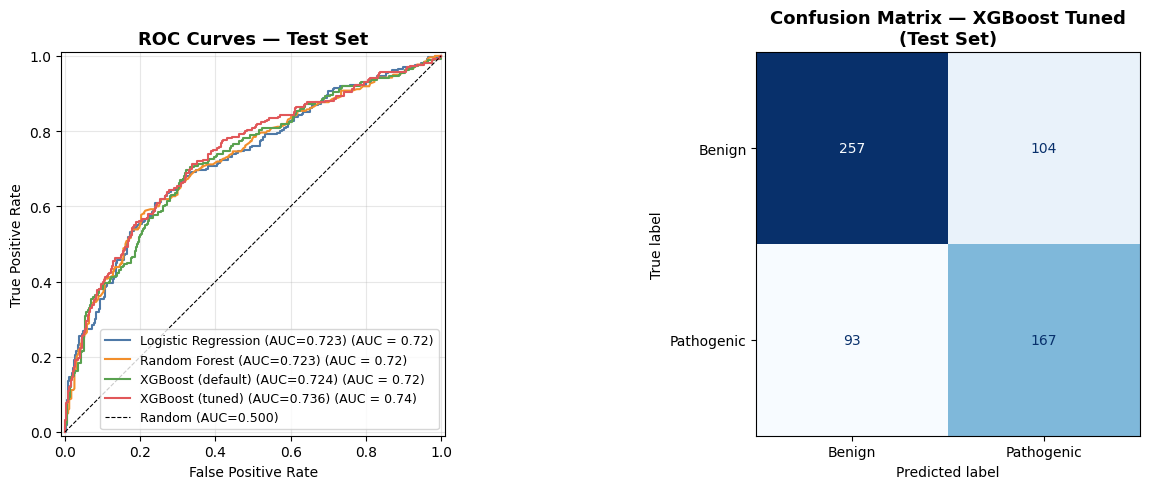


Plot saved: test_set_evaluation.png


In [59]:
# ── 13d: ROC curves for all 4 models on one plot ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROC curves
ax = axes[0]
colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']

for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['y_pred_proba'],
        name=f"{name} (AUC={res['auc']:.3f})",
        ax=ax, color=color
    )

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.500)')
ax.set_title('ROC Curves — Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Right: Confusion matrix for best model only
ax2 = axes[1]
ConfusionMatrixDisplay.from_predictions(
    y_test,
    results['XGBoost (tuned)']['y_pred'],
    display_labels=['Benign', 'Pathogenic'],
    colorbar=False,
    ax=ax2,
    cmap='Blues'
)
ax2.set_title('Confusion Matrix — XGBoost Tuned\n(Test Set)',
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('test_set_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: test_set_evaluation.png")

Optimal threshold (Youden's J): 0.4651
  Sensitivity (Recall): 0.7115
  Specificity:          0.6620

─── Test set metrics at optimal threshold (0.465) ───
  MCC:       0.3686
  Recall:    0.7115
  Precision: 0.6026
  F1:        0.6526

─── Index alignment check ───
  vus_results rows:   812
  X_vus_reset rows:   812
  Counts match:       True

─── VUS Reclassification (n=812) ───

Using default threshold (0.50):
  Reclassified as Pathogenic: 255
  Reclassified as Benign:     557

Using optimal threshold (0.465):
  Reclassified as Pathogenic: 292
  Reclassified as Benign:     520

─── Top 15 VUS most likely Pathogenic ───
Variant  Annotation  Source  P_Pathogenic  Pred_default_0.50  Pred_optimal_0.465
   G65R Unannotated ClinVar      0.937061                  1                   1
  G963R Unannotated ClinVar      0.934349                  1                   1
   C81R Unannotated ClinVar      0.928432                  1                   1
  C641R Unannotated ClinVar      0.927593     

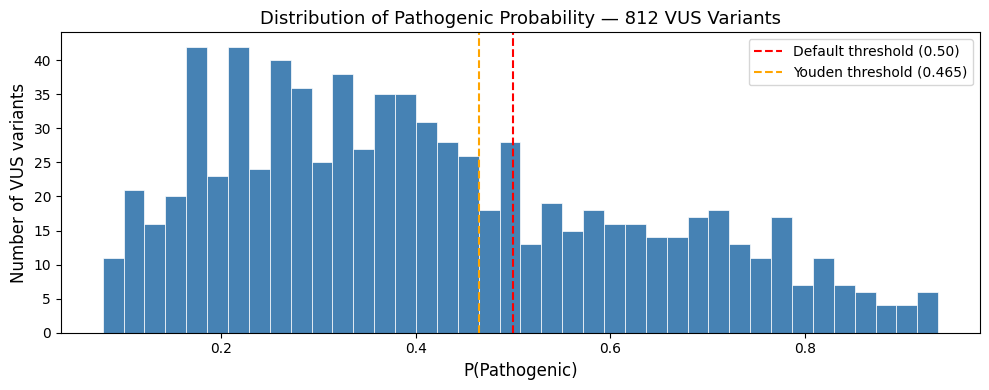

Plot saved: vus_reclassification.png


In [61]:
# ─── Section 14: Threshold optimisation + VUS scoring ─────────────────────
from sklearn.metrics import precision_recall_curve, roc_curve

# ── 14a: Find the threshold that maximises recall at acceptable precision ──
y_proba_test = results['XGBoost (tuned)']['y_pred_proba']

fprs, tprs, thresholds_roc = roc_curve(y_test, y_proba_test)

# Youden's J = Sensitivity + Specificity - 1
# Maximising J finds the threshold with the best overall balance
youden_j      = tprs - fprs
best_idx      = np.argmax(youden_j)
best_threshold = thresholds_roc[best_idx]

print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")
print(f"  Sensitivity (Recall): {tprs[best_idx]:.4f}")
print(f"  Specificity:          {1 - fprs[best_idx]:.4f}")

# Apply optimal threshold to test set
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)

print(f"\n─── Test set metrics at optimal threshold ({best_threshold:.3f}) ───")
print(f"  MCC:       {matthews_corrcoef(y_test, y_pred_optimal):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_optimal):.4f}")

# ── 14b: Index-safe VUS setup ─────────────────────────────────────────────
# 'vus' has all metadata columns (Variant, Significance, Annotation, Source)
# X_vus_pruned has only the 49 model features — same rows, same index
#
# We reset_index on both so that numpy array assignment is position-safe.
# Without reset_index, pandas aligns by INDEX LABEL not by position —
# a probability computed for row 3 could be attached to row 47.

vus_results = vus.copy().reset_index(drop=True)
X_vus_reset = X_vus_pruned.reset_index(drop=True)

# Verify alignment before predicting
print(f"\n─── Index alignment check ───")
print(f"  vus_results rows:   {len(vus_results)}")
print(f"  X_vus_reset rows:   {len(X_vus_reset)}")
print(f"  Counts match:       {len(vus_results) == len(X_vus_reset)}")

# ── 14c: Predict on VUS ───────────────────────────────────────────────────
vus_proba        = best_xgb.predict_proba(X_vus_reset)[:, 1]
vus_pred_default = (vus_proba >= 0.50).astype(int)
vus_pred_optimal = (vus_proba >= best_threshold).astype(int)

# Attach probabilities and predictions back to metadata
vus_results['P_Pathogenic']      = vus_proba
vus_results['Pred_default_0.50'] = vus_pred_default
vus_results[f'Pred_optimal_{best_threshold:.3f}'] = vus_pred_optimal

# Summary counts
print(f"\n─── VUS Reclassification (n={len(vus_results)}) ───")
print(f"\nUsing default threshold (0.50):")
print(f"  Reclassified as Pathogenic: {vus_pred_default.sum()}")
print(f"  Reclassified as Benign:     {(vus_pred_default == 0).sum()}")
print(f"\nUsing optimal threshold ({best_threshold:.3f}):")
print(f"  Reclassified as Pathogenic: {vus_pred_optimal.sum()}")
print(f"  Reclassified as Benign:     {(vus_pred_optimal == 0).sum()}")

# ── 14d: Inspect top reclassified variants ───────────────────────────────
vus_sorted = vus_results.sort_values('P_Pathogenic', ascending=False)

# Only show columns that exist in the DataFrame
display_cols = ['Variant', 'Annotation', 'Source', 'P_Pathogenic',
                'Pred_default_0.50',
                f'Pred_optimal_{best_threshold:.3f}']
display_cols = [c for c in display_cols if c in vus_sorted.columns]

print(f"\n─── Top 15 VUS most likely Pathogenic ───")
print(vus_sorted[display_cols].head(15).to_string(index=False))

print(f"\n─── Top 10 VUS most likely Benign ───")
print(vus_sorted[display_cols].tail(10).to_string(index=False))

# ── 14e: Distribution of pathogenic probabilities across all VUS ──────────
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(vus_proba, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(0.50,          color='red',    linestyle='--', linewidth=1.5,
            label=f'Default threshold (0.50)')
plt.axvline(best_threshold, color='orange', linestyle='--', linewidth=1.5,
            label=f'Youden threshold ({best_threshold:.3f})')
plt.xlabel('P(Pathogenic)', fontsize=12)
plt.ylabel('Number of VUS variants', fontsize=12)
plt.title('Distribution of Pathogenic Probability — 812 VUS Variants', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('vus_reclassification.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: vus_reclassification.png")

Features with non-zero importance: 48 / 49

Top 20 features by gain:
             Feature      Gain
 Envision_delta_PSIC 22.916004
  Consurf_x_Envision 20.108023
      Demask_entropy  8.801972
       Demask_matrix  8.369186
       Consurf_score  7.431324
    Envision_deltaPI  6.736584
   Envision_AA2_PSIC  6.558173
            HP_12_00  6.270493
               Ionic  6.245612
            PP:11.00  6.235642
Envision_deltavolume  6.164742
   Envision_AA1_PSIC  6.113015
                 VDW  6.050213
             HP:7.00  5.969823
             HP_1_50  5.913074
             HH:4.00  5.902256
 Envision_AA2_weight  5.881207
               Hydro  5.809245
Envision_deltaWeight  5.804635
    Demask_log2f_var  5.761013


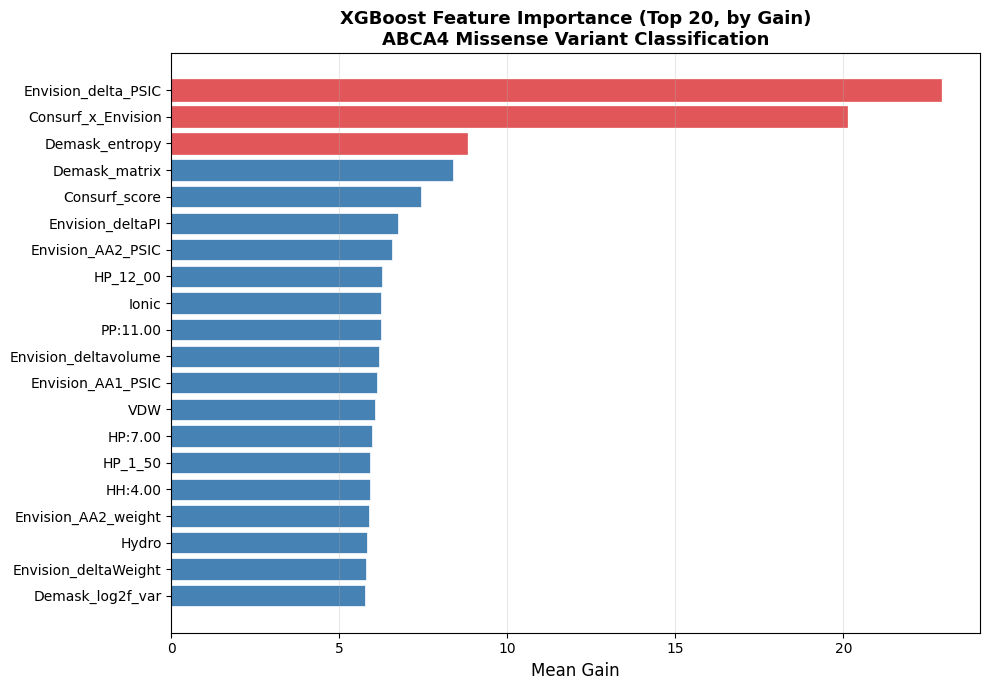

Plot saved: feature_importance.png

VUS results saved: vus_reclassification_results.csv
  Total VUS variants: 812
  Reclassified Pathogenic (Youden): 292
  Reclassified Benign (Youden):     520

─── High-confidence reclassifications ───
  P(Pathogenic) ≥ 0.80 → Likely Pathogenic: 43
  P(Pathogenic) ≤ 0.20 → Likely Benign:     126
  Uncertain zone (0.20–0.80):                643

─── High-confidence Pathogenic variants ───
Variant  Annotation  Source  P_Pathogenic  Pred_default_0.50  Pred_optimal_0.465
   G65R Unannotated ClinVar      0.937061                  1                   1
  G963R Unannotated ClinVar      0.934349                  1                   1
   C81R Unannotated ClinVar      0.928432                  1                   1
  C641R Unannotated ClinVar      0.927593                  1                   1
   N79K Unannotated ClinVar      0.920306                  1                   1
  G803R Unannotated ClinVar      0.915710                  1                   1
  G805D

In [62]:
# ─── Section 15: Feature importance + export results ──────────────────────
import matplotlib.pyplot as plt
import pandas as pd

# ── 15a: XGBoost feature importance (gain) ────────────────────────────────
# XGBoost tracks three importance types:
#   'weight'  → how many times a feature is used to split across all trees
#   'gain'    → average improvement in loss function when a feature is used
#   'cover'   → average number of training samples affected by a feature's splits
#
# 'gain' is the most meaningful — a feature used rarely but with large gain
# is more important than one used often with tiny gain

importance_dict = best_xgb.get_booster().get_score(importance_type='gain')

# Convert to DataFrame and sort
importance_df = (
    pd.DataFrame.from_dict(importance_dict, orient='index', columns=['Gain'])
    .sort_values('Gain', ascending=False)
    .reset_index()
    .rename(columns={'index': 'Feature'})
)

print(f"Features with non-zero importance: {len(importance_df)} / {X_train_pruned.shape[1]}")
print("\nTop 20 features by gain:")
print(importance_df.head(20).to_string(index=False))

# ── 15b: Plot top 20 features ─────────────────────────────────────────────
top_n = 20
plot_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(plot_df['Feature'][::-1], plot_df['Gain'][::-1],
               color='steelblue', edgecolor='white', linewidth=0.5)

# Colour the top 3 features differently to highlight them
for i, bar in enumerate(bars):
    if i >= top_n - 3:       # last 3 in reversed list = top 3
        bar.set_color('#E15759')

ax.set_xlabel('Mean Gain', fontsize=12)
ax.set_title(f'XGBoost Feature Importance (Top {top_n}, by Gain)\n'
             f'ABCA4 Missense Variant Classification', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: feature_importance.png")

# ── 15c: Export VUS reclassification results to CSV ───────────────────────
# Save the full ranked VUS table for downstream biological analysis
output_cols = ['Variant', 'Annotation', 'Source', 'P_Pathogenic',
               'Pred_default_0.50',
               f'Pred_optimal_{best_threshold:.3f}']
output_cols = [c for c in output_cols if c in vus_sorted.columns]

vus_sorted[output_cols].to_csv('vus_reclassification_results.csv', index=False)
print(f"\nVUS results saved: vus_reclassification_results.csv")
print(f"  Total VUS variants: {len(vus_sorted)}")
print(f"  Reclassified Pathogenic (Youden): {vus_pred_optimal.sum()}")
print(f"  Reclassified Benign (Youden):     {(vus_pred_optimal == 0).sum()}")

# ── 15d: High-confidence reclassifications only ───────────────────────────
# Variants with P > 0.80 or P < 0.20 are high-confidence reclassifications
# These are the most defensible for clinical follow-up
high_conf_path   = vus_sorted[vus_sorted['P_Pathogenic'] >= 0.80]
high_conf_benign = vus_sorted[vus_sorted['P_Pathogenic'] <= 0.20]

print(f"\n─── High-confidence reclassifications ───")
print(f"  P(Pathogenic) ≥ 0.80 → Likely Pathogenic: {len(high_conf_path)}")
print(f"  P(Pathogenic) ≤ 0.20 → Likely Benign:     {len(high_conf_benign)}")
print(f"  Uncertain zone (0.20–0.80):                "
      f"{len(vus_sorted) - len(high_conf_path) - len(high_conf_benign)}")

print(f"\n─── High-confidence Pathogenic variants ───")
print(high_conf_path[output_cols].to_string(index=False))